In [7]:

import pandas as pd
import numpy as np
# from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import ipywidgets as widgets

import re

from sklearn.metrics import accuracy_score, classification_report

In [8]:
train_data=pd.read_csv('Data/train.csv')

In [9]:
evaluation_data=pd.read_csv('Data/eval.csv')

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      12000 non-null  int64 
 1   text    12000 non-null  object
 2   label   12000 non-null  object
dtypes: int64(1), object(2)
memory usage: 281.4+ KB


In [11]:
((train_data.isnull().sum()/train_data.shape[0])).sort_values(ascending=False)

id       0.0
text     0.0
label    0.0
dtype: float64

In [12]:
train_data['label'].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

In [13]:
tr_data=train_data.copy()

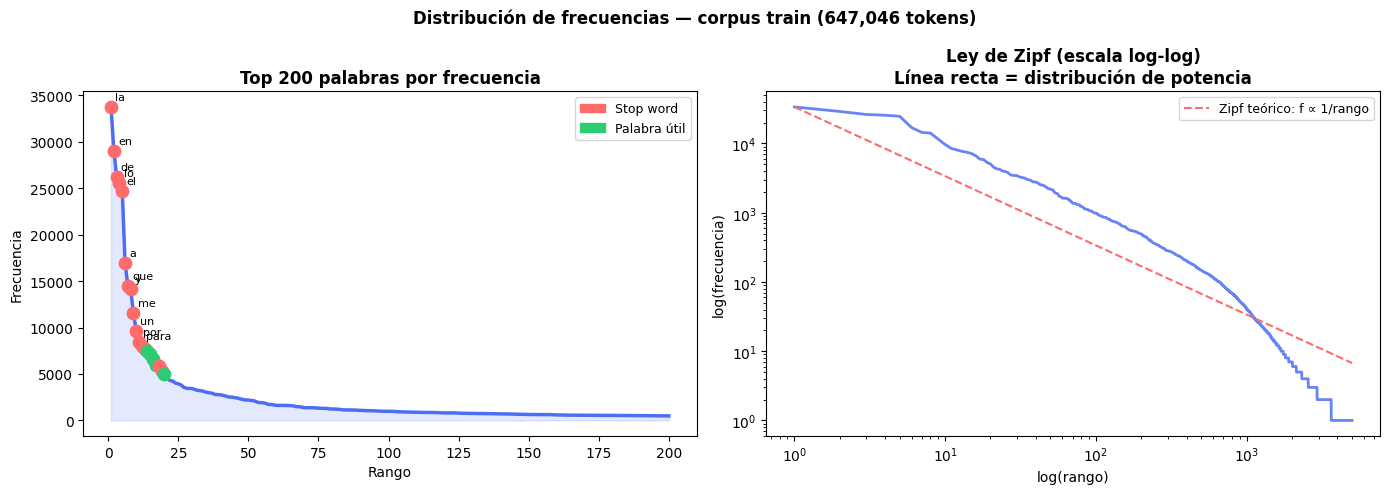

Las 10 palabras más frecuentes cubren el 31.8% del corpus total.
Top 10: ['la', 'en', 'de', 'lo', 'el', 'a', 'que', 'y', 'me', 'un']


In [14]:
# Ley de Zipf sobre el corpus real
from collections import Counter
import re
import matplotlib.pyplot as plt

# Contar todas las palabras del corpus
todas_las_palabras = []
for texto in tr_data['text'].dropna():
    tokens_raw = re.sub(r'[^\w\s]', '', texto.lower()).split()
    todas_las_palabras.extend(tokens_raw)

contador = Counter(todas_las_palabras)
palabras_ord = [p for p, _ in contador.most_common(5000)]
freqs = [contador[p] for p in palabras_ord]
rangos = list(range(1, len(freqs)+1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala normal
axes[0].plot(rangos[:200], freqs[:200], color='#4C6EF5', lw=2.5)
axes[0].fill_between(rangos[:200], freqs[:200], alpha=0.15, color='#4C6EF5')
# Marcar las primeras 10 stop words
stop_en = set(stopwords.words('spanish'))
top20 = palabras_ord[:20]
for i, (rango, freq, pal) in enumerate(zip(rangos[:20], freqs[:20], top20)):
    color_pt = '#FF6B6B' if pal in stop_en else '#2ECC71'
    axes[0].scatter(rango, freq, s=80, color=color_pt, zorder=5)
    if i < 12:
        axes[0].annotate(pal, (rango, freq),
                          xytext=(3, 5), textcoords='offset points', fontsize=8)
axes[0].set_title('Top 200 palabras por frecuencia', fontweight='bold')
axes[0].set_xlabel('Rango'); axes[0].set_ylabel('Frecuencia')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#FF6B6B',label='Stop word'),
                         Patch(color='#2ECC71',label='Palabra útil')], fontsize=9)

# Escala log-log → línea recta confirma Zipf
axes[1].loglog(rangos, freqs, color='#4C6EF5', lw=2, alpha=0.85)
# Línea teórica de Zipf
zipf_teorico = [freqs[0] / r for r in rangos]
axes[1].loglog(rangos, zipf_teorico, color='#FF6B6B', lw=1.5,
               linestyle='--', label='Zipf teórico: f ∝ 1/rango')
axes[1].set_title('Ley de Zipf (escala log-log)\nLínea recta = distribución de potencia',
                   fontweight='bold')
axes[1].set_xlabel('log(rango)'); axes[1].set_ylabel('log(frecuencia)')
axes[1].legend(fontsize=9)

plt.suptitle(f'Distribución de frecuencias — corpus train ({len(todas_las_palabras):,} tokens)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

top10 = contador.most_common(10)
total = sum(contador.values())
cobertura = sum(f for _,f in top10) / total
print(f'Las 10 palabras más frecuentes cubren el {cobertura:.1%} del corpus total.')
print(f'Top 10: {[p for p,_ in top10]}')

In [15]:
tr_data.value_counts()

id     text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                label   
11960  Lo compré a comienzos de año, tardó como cuatro días en llegar y lo armo y desarmo seguido porque lo muevo entre la oficina y la casa. Con el paso de las semanas nomás se nota que el ensamblaje luce mal terminado con el uso diario.                                                                                                                                                                                                                                                             negativo 

In [16]:
tr_data[['text', 'label']].head(10)

,text,label
0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,Se lo compré a un familiar después de pensarla...,positivo
2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,Compré esto en línea y llegó en unos tres días...,negativo
4,Compré este kit el mes pasado porque necesitab...,positivo
5,Lo pedí a mediados de mes y llegó en tres días...,negativo
6,Comparto mi experiencia con este aparato que l...,positivo
7,La compré a mediados de año por internet y tar...,negativo
8,"Compré esto la semana pasada en línea, llegó e...",positivo
9,Compré esto en una tienda por departamentos ha...,negativo


In [17]:
n_duplicados = int(train_data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

Número de registros duplicados: 0


In [18]:
dup_counts = (train_data[["id","text"]].groupby('id').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["id","Count"]].values:    
    print(f"id={id_} → {n} apariciones")

In [19]:
# Función de limpieza completa
stemmer = SnowballStemmer('spanish')
stop_en = set(stopwords.words('spanish'))

def limpiar_texto(texto, idioma='sp', aplicar_stemming=True):
    if not isinstance(texto, str):
        return ''
    # 1. Normalización
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    texto = re.sub(r'\d+', '', texto)  # eliminar números
    texto = re.sub(r'\s+', ' ', texto).strip()
    # 2. Tokenización
    tokens = texto.split()
    # 3. Stop words
    sw = stop_en if idioma == 'sp' else set(stopwords.words('spanish'))
    # 4. Stemming
    if aplicar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Aplicar al dataset
tr_data['text'] = tr_data['text'].apply(limpiar_texto)

# Comparación antes / después
idx = 5
print('ORIGINAL (primeros 300 chars):')
print(train_data['text'].iloc[idx][:300])
print('\nPROCESADO:')
print(tr_data['text'].iloc[idx][:300])
print(f'\nReducción de tokens: {len(train_data["text"].iloc[idx].split())} → {len(tr_data["text"].iloc[idx].split())}')

ORIGINAL (primeros 300 chars):
Lo pedí a mediados de mes y llegó en tres días hábiles a casa de mi hermana, donde lo dejé instalado. La ficha técnica indica que funciona con corriente de 110 voltios, igual que los contactos que tenemos en el cuarto. En cuanto a la comodidad, fue un error de compra.

PROCESADO:
lo ped a medi de mes y lleg en tres dias habil a cas de mi herman dond lo dej instal la fich tecnic indic que funcion con corrient de volti igual que los contact que ten en el cuart en cuant a la comod fue un error de compr

Reducción de tokens: 51 → 50


In [20]:
tr_data.value_counts()

id     text                                                                                                                                                                                                                                                                                                                                                                                                                     label   
11960  lo compr a comienz de año tard com cuatr dias en lleg y lo armo y desarm segu porqu lo muev entre la oficin y la cas con el pas de las seman nomas se not que el ensamblaj luc mal termin con el uso diari                                                                                                                                                                                                               negativo    1
11961  en poc palabr mi experient con este reloj me lo lleg el mart por la transport de siempr el mism mensajer de tod mis ped y el empaqu ven bi

In [21]:
tfidf_vec = TfidfVectorizer(max_features=10_000, min_df=3, stop_words=None)
X_tfidf = tfidf_vec.fit_transform(tr_data['text'])
vocab_tfidf = tfidf_vec.get_feature_names_out()

# Paleta de colores por clase
paleta_clases = ['#FF6B6B', '#4C6EF5', '#2ECC71']
colores_cat = dict(zip(tr_data['label'].unique(), paleta_clases))

print(f'Shape de la matriz TF-IDF: {X_tfidf.shape}')
print(f'  → {X_tfidf.shape[0]:,} documentos × {X_tfidf.shape[1]:,} palabras del vocabulario')
print(f'  → {X_tfidf.nnz:,} valores no-cero de {X_tfidf.shape[0]*X_tfidf.shape[1]:,} posibles')

Shape de la matriz TF-IDF: (12000, 1651)
  → 12,000 documentos × 1,651 palabras del vocabulario
  → 487,978 valores no-cero de 19,812,000 posibles


In [22]:
# Widget: explorar el TF-IDF de cualquier documento del corpus
def explorar_documento_tfidf(doc_idx=0, top_n=12):
    clase = tr_data['label'].iloc[doc_idx]
    texto = tr_data['text'].iloc[doc_idx]
    vec_doc = X_tfidf[doc_idx].toarray().flatten()
    top_idx = np.argsort(vec_doc)[-top_n:]
    top_words = vocab_tfidf[top_idx]
    top_vals  = vec_doc[top_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    color = colores_cat.get(clase, '#888888')
    axes[0].barh(top_words, top_vals, color=color, alpha=0.85, edgecolor='white')
    axes[0].set_title(f'Top {top_n} términos (TF-IDF)\nDocumento {doc_idx} — {clase}',
                       fontweight='bold')
    axes[0].set_xlabel('Peso TF-IDF')

    # Texto del documento
    axes[1].axis('off')
    preview = texto[:600] if len(texto) > 600 else texto
    axes[1].text(0.02, 0.95, f'[{clase}]', transform=axes[1].transAxes,
                  fontsize=9, color=color, fontweight='bold', va='top')
    axes[1].text(0.02, 0.88, preview, transform=axes[1].transAxes,
                  fontsize=7.5, va='top', wrap=True,
                  bbox=dict(boxstyle='round', fc='#F8F8F8', alpha=0.9))

    plt.tight_layout(); plt.show()

widgets.interact(
    explorar_documento_tfidf,
    doc_idx=widgets.IntSlider(value=0, min=0, max=len(tr_data)-1, step=1,
                               description='Documento:', continuous_update=False,
                               style={'description_width':'90px'},
                               layout=widgets.Layout(width='500px')),
    top_n=widgets.IntSlider(value=12, min=5, max=20, step=1,
                             description='Top N términos:', continuous_update=False,
                             style={'description_width':'110px'}));

interactive(children=(IntSlider(value=0, continuous_update=False, description='Documento:', layout=Layout(widt…

In [23]:


X = train_data['text']
y = train_data['label']


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


pipeline_rl = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=limpiar_texto,  
        max_features=10_000,
        min_df=3,
        stop_words=None
    )),
    ('modelo', LogisticRegression(
        solver='lbfgs',
        C=1.0,
        max_iter=1000
    ))
])


pipeline_rl.fit(X_train, y_train)


y_pred = pipeline_rl.predict(X_val)


print(f'Accuracy de validación: {accuracy_score(y_val, y_pred):.4f}')
print(classification_report(y_val, y_pred, zero_division=0))

Accuracy de validación: 0.7262
              precision    recall  f1-score   support

    negativo       0.62      0.62      0.62       843
     neutral       0.96      0.99      0.98       715
    positivo       0.62      0.61      0.61       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.73      0.72      2400

